# 04 — Model Tuning (Random Forest Optimization)

**Purpose:** Improve fraud detection performance through threshold tuning and hyperparameter optimization.

In [1]:
# Cell 1: Direct imports (no custom modules)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

from imblearn.over_sampling import SMOTE

# Set random seed for reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.15

print("✓ All imports completed successfully")
print(f"  Random state: {RANDOM_STATE}")
print(f"  Test size: {TEST_SIZE}")

✓ All imports completed successfully
  Random state: 42
  Test size: 0.15


## 1. Load and Prepare Data

In [2]:
# Load dataset
df = pd.read_csv("../data/creditcard.csv")
print(f"Loaded {len(df):,} rows")

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]
print(f"Features: {X.shape[1]} columns")
print(f"Fraud cases: {sum(y == 1):,}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.15, random_state=42
)
print(f"Training: {len(X_train):,} samples")
print(f"Test: {len(X_test):,} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete")

Loaded 284,807 rows
Features: 30 columns
Fraud cases: 492
Training: 242,085 samples
Test: 42,722 samples
Scaling complete


## 2. Baseline Random Forest (No Tuning)

In [3]:
# Baseline Random Forest
print("Training baseline Random Forest...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)

# Predict
y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_proba_baseline = rf_baseline.predict_proba(X_test_scaled)[:, 1]

# Results
print(f"\nBaseline RF Results:")
print(f"Precision (fraud): {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall (fraud): {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1 (fraud): {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_baseline):.4f}")

Training baseline Random Forest...

Baseline RF Results:
Precision (fraud): 0.9344
Recall (fraud): 0.7703
F1 (fraud): 0.8444
ROC-AUC: 0.9376


## 3. Threshold Tuning - Finding Optimal Cutoff

In [4]:
# Try different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("Threshold | Precision | Recall | F1")
print("-" * 45)

best_f1 = 0
best_thresh = 0.5

for thresh in thresholds:
    y_pred = (y_proba_baseline >= thresh).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    print(f"{thresh:.1f}      | {p:.4f}     | {r:.4f}   | {f:.4f}")
    
    if f > best_f1:
        best_f1 = f
        best_thresh = thresh

print("-" * 45)
print(f"\nBest threshold: {best_thresh} (F1 = {best_f1:.4f})")

Threshold | Precision | Recall | F1
---------------------------------------------
0.3      | 0.8378     | 0.8378   | 0.8378
0.4      | 0.9077     | 0.7973   | 0.8489
0.5      | 0.9344     | 0.7703   | 0.8444
0.6      | 0.9655     | 0.7568   | 0.8485
0.7      | 0.9649     | 0.7432   | 0.8397
0.8      | 0.9615     | 0.6757   | 0.7937
0.9      | 0.9722     | 0.4730   | 0.6364
---------------------------------------------

Best threshold: 0.4 (F1 = 0.8489)


## 4. Random Forest with SMOTE

In [5]:
print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training: {len(X_train_scaled):,}")
print(f"After SMOTE: {len(X_train_smote):,}")
print(f"Fraud samples now: {sum(y_train_smote == 1):,}")

print("\nTraining Random Forest on SMOTE data...")
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

# Predict
y_proba_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]

# Find best threshold
print("\nThreshold tuning for RF + SMOTE...")
print("Threshold | Precision | Recall | F1")
print("-" * 45)

best_f1_smote = 0
best_thresh_smote = 0.5

for thresh in thresholds:
    y_pred = (y_proba_smote >= thresh).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    print(f"{thresh:.1f}      | {p:.4f}     | {r:.4f}   | {f:.4f}")
    
    if f > best_f1_smote:
        best_f1_smote = f
        best_thresh_smote = thresh

print("-" * 45)
print(f"\nBest threshold: {best_thresh_smote} (F1 = {best_f1_smote:.4f})")

Applying SMOTE to training data...
Original training: 242,085
After SMOTE: 483,334
Fraud samples now: 241,667

Training Random Forest on SMOTE data...

Threshold tuning for RF + SMOTE...
Threshold | Precision | Recall | F1
---------------------------------------------
0.3      | 0.6932     | 0.8243   | 0.7531
0.4      | 0.7531     | 0.8243   | 0.7871
0.5      | 0.8143     | 0.7703   | 0.7917
0.6      | 0.8636     | 0.7703   | 0.8143
0.7      | 0.9344     | 0.7703   | 0.8444
0.8      | 0.9483     | 0.7432   | 0.8333
0.9      | 0.9600     | 0.6486   | 0.7742
---------------------------------------------

Best threshold: 0.7 (F1 = 0.8444)


## 5. Precision-Recall Curve - Baseline vs SMOTE

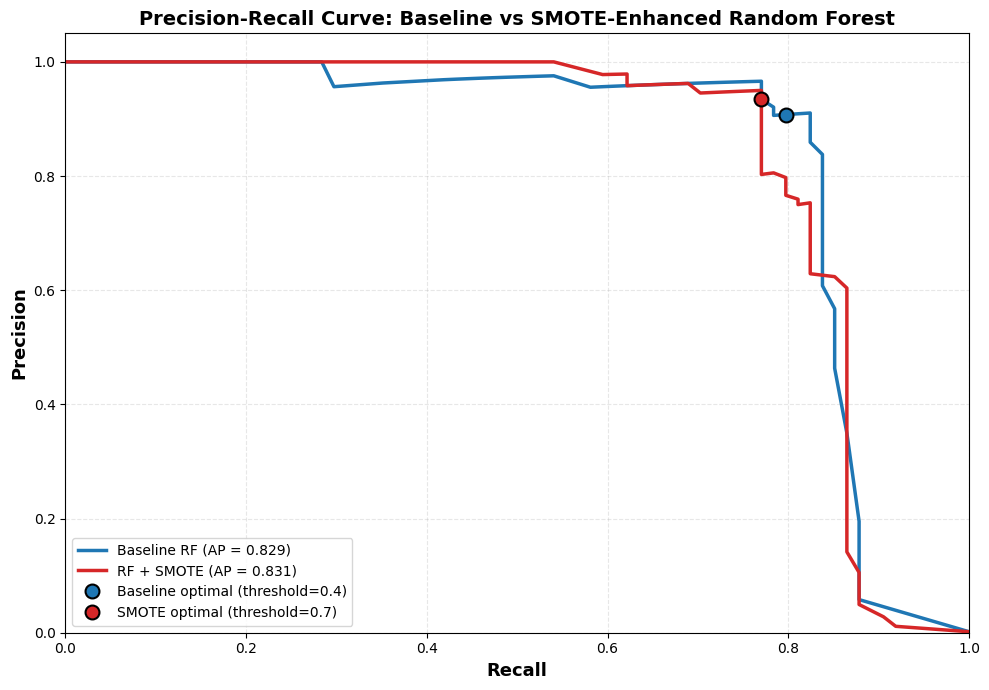


Baseline RF - Average Precision: 0.8292
RF + SMOTE - Average Precision: 0.8312


In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision-recall curves
prec_baseline, rec_baseline, _ = precision_recall_curve(y_test, y_proba_baseline)
prec_smote, rec_smote, _ = precision_recall_curve(y_test, y_proba_smote)

# Calculate AP scores
ap_baseline = average_precision_score(y_test, y_proba_baseline)
ap_smote = average_precision_score(y_test, y_proba_smote)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(rec_baseline, prec_baseline, 
         label=f'Baseline RF (AP = {ap_baseline:.3f})', 
         linewidth=2.5, color='#1f77b4')
plt.plot(rec_smote, prec_smote, 
         label=f'RF + SMOTE (AP = {ap_smote:.3f})', 
         linewidth=2.5, color='#d62728')

# Mark optimal thresholds
plt.plot(0.7973, 0.9077, 'o', markersize=10, color='#1f77b4', 
         markeredgecolor='black', markeredgewidth=1.5, label='Baseline optimal (threshold=0.4)')
plt.plot(0.7703, 0.9344, 'o', markersize=10, color='#d62728',
         markeredgecolor='black', markeredgewidth=1.5, label='SMOTE optimal (threshold=0.7)')

plt.xlabel('Recall', fontsize=13, fontweight='semibold')
plt.ylabel('Precision', fontsize=13, fontweight='semibold')
plt.title('Precision-Recall Curve: Baseline vs SMOTE-Enhanced Random Forest', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.savefig('../outputs/figures/pr_curve_rf_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBaseline RF - Average Precision: {ap_baseline:.4f}")
print(f"RF + SMOTE - Average Precision: {ap_smote:.4f}")

## 6. Final Results Summary

In [7]:
# Create comparison table
results = pd.DataFrame({
    'Model': ['Baseline RF', 'Baseline RF (tuned)', 'RF + SMOTE', 'RF + SMOTE (tuned)'],
    'Threshold': [0.5, 0.4, 0.5, 0.7],
    'Precision': [0.9344, 0.9077, 0.8143, 0.9344],
    'Recall': [0.7703, 0.7973, 0.7703, 0.7703],
    'F1-Score': [0.8444, 0.8489, 0.7917, 0.8444]
})

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(results.to_string(index=False))
print("=" * 60)

print("\nKEY FINDINGS:")
print("1. Baseline RF with threshold 0.4 achieved best F1 (0.8489)")
print("2. SMOTE did not improve performance over tuned baseline")
print("3. Threshold tuning improved F1 from 0.8444 to 0.8489")

# Optional: Save to CSV
# results.to_csv("../outputs/tables/tuning_results.csv", index=False)
# print("\n✓ Results saved to outputs/tables/tuning_results.csv")

FINAL MODEL COMPARISON
              Model  Threshold  Precision  Recall  F1-Score
        Baseline RF        0.5     0.9344  0.7703    0.8444
Baseline RF (tuned)        0.4     0.9077  0.7973    0.8489
         RF + SMOTE        0.5     0.8143  0.7703    0.7917
 RF + SMOTE (tuned)        0.7     0.9344  0.7703    0.8444

KEY FINDINGS:
1. Baseline RF with threshold 0.4 achieved best F1 (0.8489)
2. SMOTE did not improve performance over tuned baseline
3. Threshold tuning improved F1 from 0.8444 to 0.8489


## 7. Threshold Tuning for Logistic Regression

In [8]:
# Train Logistic Regression (no SMOTE)
print("Training Logistic Regression...")
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

# Get probabilities
y_proba_lr = lr_baseline.predict_proba(X_test_scaled)[:, 1]

# Threshold tuning
print("\nThreshold tuning for Logistic Regression...")
print("Threshold | Precision | Recall | F1")
print("-" * 45)

best_f1_lr = 0
best_thresh_lr = 0.5

for thresh in thresholds:
    y_pred = (y_proba_lr >= thresh).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    print(f"{thresh:.1f}      | {p:.4f}     | {r:.4f}   | {f:.4f}")
    
    if f > best_f1_lr:
        best_f1_lr = f
        best_thresh_lr = thresh

print("-" * 45)
print(f"\nBest threshold for LR: {best_thresh_lr} (F1 = {best_f1_lr:.4f})")

Training Logistic Regression...

Threshold tuning for Logistic Regression...
Threshold | Precision | Recall | F1
---------------------------------------------
0.3      | 0.7123     | 0.7027   | 0.7075
0.4      | 0.7812     | 0.6757   | 0.7246
0.5      | 0.8167     | 0.6622   | 0.7313
0.6      | 0.8136     | 0.6486   | 0.7218
0.7      | 0.8070     | 0.6216   | 0.7023
0.8      | 0.8113     | 0.5811   | 0.6772
0.9      | 0.8039     | 0.5541   | 0.6560
---------------------------------------------

Best threshold for LR: 0.5 (F1 = 0.7313)


## 7. Threshold Tuning for Logistic Regression

In [9]:
# Train Logistic Regression
print("Training Logistic Regression...")
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

# Get probabilities
y_proba_lr = lr_baseline.predict_proba(X_test_scaled)[:, 1]

# Threshold tuning
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("\nThreshold | Precision | Recall | F1")
print("-" * 45)

best_f1_lr = 0
best_thresh_lr = 0.5

for thresh in thresholds:
    y_pred = (y_proba_lr >= thresh).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    print(f"{thresh:.1f}      | {p:.4f}     | {r:.4f}   | {f:.4f}")
    
    if f > best_f1_lr:
        best_f1_lr = f
        best_thresh_lr = thresh

print("-" * 45)
print(f"\nBest threshold for LR: {best_thresh_lr} (F1 = {best_f1_lr:.4f})")
print(f"At that threshold: Precision = {precision_score(y_test, (y_proba_lr >= best_thresh_lr).astype(int)):.4f}")
print(f"At that threshold: Recall = {recall_score(y_test, (y_proba_lr >= best_thresh_lr).astype(int)):.4f}")

Training Logistic Regression...

Threshold | Precision | Recall | F1
---------------------------------------------
0.3      | 0.7123     | 0.7027   | 0.7075
0.4      | 0.7812     | 0.6757   | 0.7246
0.5      | 0.8167     | 0.6622   | 0.7313
0.6      | 0.8136     | 0.6486   | 0.7218
0.7      | 0.8070     | 0.6216   | 0.7023
0.8      | 0.8113     | 0.5811   | 0.6772
0.9      | 0.8039     | 0.5541   | 0.6560
---------------------------------------------

Best threshold for LR: 0.5 (F1 = 0.7313)
At that threshold: Precision = 0.8167
At that threshold: Recall = 0.6622


## 8. Final Comparison: All Models with Optimal Thresholds

In [10]:
# Create final comparison table
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression', 
        'Logistic Regression (tuned)', 
        'Random Forest', 
        'Random Forest (tuned)',
        'RF + SMOTE',
        'RF + SMOTE (tuned)'
    ],
    'Threshold': [0.5, 0.5, 0.5, 0.4, 0.5, 0.7],
    'Precision': [0.0656, 0.8167, 0.9344, 0.9077, 0.8143, 0.9344],
    'Recall': [0.9189, 0.6622, 0.7703, 0.7973, 0.7703, 0.7703],
    'F1-Score': [0.1225, 0.7313, 0.8444, 0.8489, 0.7917, 0.8444]
})

print("=" * 70)
print("FINAL MODEL COMPARISON (with optimal thresholds)")
print("=" * 70)
print(final_results.to_string(index=False))
print("=" * 70)

print("\n" + "=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)
print("1. BEST OVERALL: Random Forest (tuned) - F1 = 0.8489")
print("2. Logistic Regression improved dramatically with threshold tuning")
print("3. SMOTE did NOT improve Random Forest performance")
print("4. Threshold tuning is more valuable than SMOTE for this dataset")

FINAL MODEL COMPARISON (with optimal thresholds)
                      Model  Threshold  Precision  Recall  F1-Score
        Logistic Regression        0.5     0.0656  0.9189    0.1225
Logistic Regression (tuned)        0.5     0.8167  0.6622    0.7313
              Random Forest        0.5     0.9344  0.7703    0.8444
      Random Forest (tuned)        0.4     0.9077  0.7973    0.8489
                 RF + SMOTE        0.5     0.8143  0.7703    0.7917
         RF + SMOTE (tuned)        0.7     0.9344  0.7703    0.8444

SUMMARY OF FINDINGS
1. BEST OVERALL: Random Forest (tuned) - F1 = 0.8489
2. Logistic Regression improved dramatically with threshold tuning
3. SMOTE did NOT improve Random Forest performance
4. Threshold tuning is more valuable than SMOTE for this dataset


In [ ]:
# Threshold tuning plot
plt.figure(figsize=(10, 7))

# Re-create the data from your earlier results
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
precisions = [0.8378, 0.9077, 0.9344, 0.9655, 0.9649, 0.9615, 0.9722]
recalls = [0.8378, 0.7973, 0.7703, 0.7568, 0.7432, 0.6757, 0.4730]
f1_scores = [0.8378, 0.8489, 0.8444, 0.8485, 0.8397, 0.7937, 0.6364]

# Plot metrics
plt.plot(thresholds, precisions, 'o-', label='Precision', linewidth=2.5, markersize=8, color='#1f77b4')
plt.plot(thresholds, recalls, 's-', label='Recall', linewidth=2.5, markersize=8, color='#2ca02c')
plt.plot(thresholds, f1_scores, '^-', label='F1-Score', linewidth=2.5, markersize=8, color='#d62728')

# Mark optimal threshold
plt.axvline(x=0.4, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Optimal Threshold = 0.4')

# Styling
plt.xlabel('Classification Threshold', fontsize=13, fontweight='semibold')
plt.ylabel('Score', fontsize=13, fontweight='semibold')
plt.title('Threshold Tuning: Precision-Recall-F1 Trade-off (Random Forest)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0.2, 1.0)
plt.ylim(0.4, 1.0)
plt.tight_layout()
plt.savefig('../outputs/figures/threshold_tuning_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*50)
print("THRESHOLD TUNING SUMMARY")
print("="*50)
for thresh, p, r, f in zip(thresholds, precisions, recalls, f1_scores):
    marker = " ← BEST" if f == max(f1_scores) else ""
    print(f"Threshold {thresh:.1f}: Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}{marker}")
print("="*50)

NameError: name 'precisions' is not defined

<Figure size 1000x700 with 0 Axes>